In [1]:
import os, time, warnings
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import shap, optuna
from scipy import stats
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.model_selection import TimeSeriesSplit
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller, kpss
from statsmodels.stats.diagnostic import acorr_ljungbox
from statsmodels.graphics.tsaplots import plot_acf
from xgboost import XGBRegressor

warnings.filterwarnings("ignore")
optuna.logging.set_verbosity(optuna.logging.WARNING)
SEED = 42
os.makedirs('figs', exist_ok=True)
plt.rcParams.update({'font.size': 11, 'savefig.dpi': 300, 'figure.dpi': 110})
print("Environment siap")

/usr/local/lib/python3.13/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Environment siap


## 1. Data

In [ ]:
DATA_PATH = 'ispu_dki_all.csv'   
df = pd.read_csv(DATA_PATH)
POL = ['pm10', 'so2', 'co', 'o3', 'no2']
for c in POL: df[c] = pd.to_numeric(df[c], errors='coerce')
df['tanggal'] = pd.to_datetime(df['tanggal'])

print(f"Jumlah baris          : {len(df):,}")
print(f"Rentang tanggal       : {df.tanggal.min().date()} s.d. {df.tanggal.max().date()}")
print(f"Tanggal unik          : {df.tanggal.nunique():,}  (1 baris = 1 hari, dilaporkan oleh 1 stasiun)")
print("\nJumlah hari per stasiun pelapor:")
print(df.stasiun.value_counts().sort_index())
print("\nPersentase missing (%):")
print((df[POL + ['pm25']].isna().mean() * 100).round(2))

Jumlah baris          : 5,538
Rentang tanggal       : 2010-01-01 s.d. 2025-02-28
Tanggal unik          : 5,538  (1 baris = 1 hari, dilaporkan oleh 1 stasiun)

Jumlah hari per stasiun pelapor:
stasiun
DKI1 (Bunderan HI)       531
DKI2 (Kelapa Gading)    1137
DKI3 (Jagakarsa)        1116
DKI4 (Lubang Buaya)     1674
DKI5 (Kebon Jeruk)      1079
Name: count, dtype: int64

Persentase missing (%):
pm10     5.69
so2      2.35
co       1.59
o3       1.88
no2      1.91
pm25    72.63
dtype: float64


Hari kalender: 5,538 | PM10 terukur: 5,223 | diisi ffill (hanya untuk fitur): 315


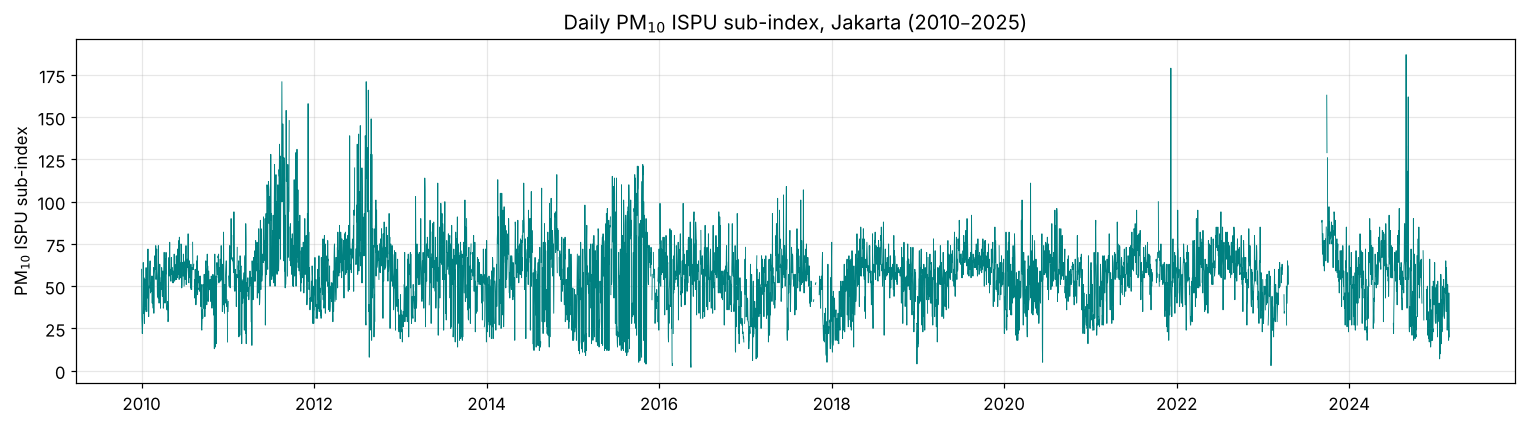

In [ ]:
daily = df.sort_values('tanggal').set_index('tanggal')
daily = daily[~daily.index.duplicated()].asfreq('D')
observed = daily['pm10'].notna()            
station = daily['stasiun']
filled = daily[POL].ffill()                 
print(f"Hari kalender: {len(daily):,} | PM10 terukur: {observed.sum():,} | diisi ffill (hanya untuk fitur): {(~observed).sum():,}")

fig, ax = plt.subplots(figsize=(14, 4))
ax.plot(daily.index, daily['pm10'], lw=0.6, color='teal')
ax.set_ylabel('PM$_{10}$ ISPU sub-index'); ax.set_title('Daily PM$_{10}$ ISPU sub-index, Jakarta (2010–2025)')
ax.grid(alpha=0.3); plt.tight_layout(); plt.savefig('figs/fig_series.png', bbox_inches='tight'); plt.show()

In [4]:
def stationarity(s, name):
    s = s.dropna(); a = adfuller(s); k = kpss(s, regression='c', nlags='auto')
    return {'Variable': name, 'ADF stat': a[0], 'ADF p': a[1], 'KPSS stat': k[0], 'KPSS p': k[1]}
st = pd.DataFrame([stationarity(daily[c], c) for c in POL])
print(st.round(4).to_string(index=False))

Variable  ADF stat  ADF p  KPSS stat  KPSS p
    pm10   -6.5162 0.0000     0.4352   0.062
     so2   -3.3491 0.0128     8.6660   0.010
      co   -6.3595 0.0000     4.2382   0.010
      o3   -3.8867 0.0021     3.4509   0.010
     no2   -4.3000 0.0004     3.5129   0.010


## 2. Feature engineering (semua fitur ≤ t−1)

In [ ]:
fe = pd.DataFrame(index=filled.index)
fe['pm10'] = daily['pm10']                      
p = filled['pm10']
for i in range(1, 8):
    fe[f'pm10_lag_{i}'] = p.shift(i)
fe['pm10_ma_3']  = p.shift(1).rolling(3).mean()
fe['pm10_ma_7']  = p.shift(1).rolling(7).mean()
fe['pm10_std_7'] = p.shift(1).rolling(7).std()
for g in ['so2', 'co', 'o3', 'no2']:
    fe[f'{g}_lag_1'] = filled[g].shift(1)
fe['co_x_o3_lag_1'] = fe['co_lag_1'] * fe['o3_lag_1']
fe['month']      = fe.index.month
fe['is_weekend'] = (fe.index.dayofweek >= 5).astype(int)
fe['season']     = fe.index.month.map(lambda m: 1 if 4 <= m <= 10 else 0)  

fe['station'] = station
fe = fe[observed].dropna()
FEATS = [c for c in fe.columns if c not in ('pm10', 'station')]
print(f"Jumlah fitur: {len(FEATS)}"); print(FEATS)
print(f"Jumlah sampel (hari terukur dengan riwayat lengkap): {len(fe):,}")

Jumlah fitur: 18
['pm10_lag_1', 'pm10_lag_2', 'pm10_lag_3', 'pm10_lag_4', 'pm10_lag_5', 'pm10_lag_6', 'pm10_lag_7', 'pm10_ma_3', 'pm10_ma_7', 'pm10_std_7', 'so2_lag_1', 'co_lag_1', 'o3_lag_1', 'no2_lag_1', 'co_x_o3_lag_1', 'month', 'is_weekend', 'season']
Jumlah sampel (hari terukur dengan riwayat lengkap): 5,215


In [6]:
n_train = int(len(fe) * 0.8)
train, test = fe.iloc[:n_train], fe.iloc[n_train:]
X_train, y_train = train[FEATS], train['pm10']
X_test,  y_test  = test[FEATS],  test['pm10']
print(f"Train: {len(train):,} hari ({train.index.min().date()} – {train.index.max().date()})")
print(f"Test : {len(test):,} hari ({test.index.min().date()} – {test.index.max().date()})")
print(f"Test mean = {y_test.mean():.2f}, std = {y_test.std():.2f}")

Train: 4,172 hari (2010-01-08 – 2021-10-22)
Test : 1,043 hari (2021-10-23 – 2025-02-28)
Test mean = 55.78, std = 18.53


## 3. Tuning RF: Optuna TPE, TimeSeriesSplit (5 fold) pada data latih saja

Selesai 30 trial dalam 77.7 s
Best CV RMSE: 16.9862
Best params : {'n_estimators': 200, 'max_depth': 9, 'min_samples_leaf': 10, 'max_features': 'log2'}


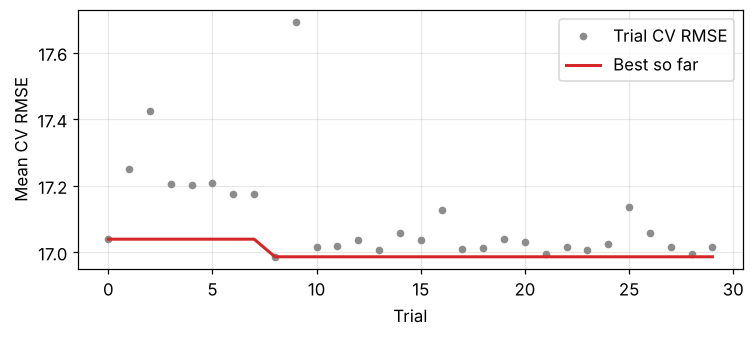

In [7]:
tscv = TimeSeriesSplit(n_splits=5)
def objective(trial):
    params = dict(
        n_estimators=trial.suggest_int('n_estimators', 100, 300, step=50),
        max_depth=trial.suggest_int('max_depth', 5, 30),
        min_samples_leaf=trial.suggest_int('min_samples_leaf', 1, 10),
        max_features=trial.suggest_categorical('max_features', ['sqrt', 'log2', 1.0]),
    )
    scores = []
    for tr_idx, va_idx in tscv.split(X_train):
        m = RandomForestRegressor(**params, random_state=SEED, n_jobs=-1)
        m.fit(X_train.iloc[tr_idx], y_train.iloc[tr_idx])
        scores.append(np.sqrt(mean_squared_error(y_train.iloc[va_idx], m.predict(X_train.iloc[va_idx]))))
    return float(np.mean(scores))

N_TRIALS = 30
t0 = time.time()
study = optuna.create_study(direction='minimize', sampler=optuna.samplers.TPESampler(seed=SEED))
study.optimize(objective, n_trials=N_TRIALS)
print(f"Selesai {N_TRIALS} trial dalam {time.time()-t0:.1f} s")
print(f"Best CV RMSE: {study.best_value:.4f}")
print(f"Best params : {study.best_params}")

hist = study.trials_dataframe()
fig, ax = plt.subplots(figsize=(7, 3.2))
ax.plot(hist['number'], hist['value'], 'o', ms=4, color='0.55', label='Trial CV RMSE')
ax.plot(hist['number'], hist['value'].cummin(), '-', color='#d62728', lw=2, label='Best so far')
ax.set_xlabel('Trial'); ax.set_ylabel('Mean CV RMSE'); ax.legend(); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('figs/fig_optuna.png', bbox_inches='tight'); plt.show()

## 4. Model akhir: RF (OOB residual) + ARIMA pada residual

Orde ARIMA terpilih (AIC): (5, 0, 4)
Waktu training RF + seleksi & fit ARIMA: 36.6 s

Ljung-Box residual OOB RF (data latih):
    lb_stat  lb_pvalue
7   21.9282     0.0026
14  29.9843     0.0077


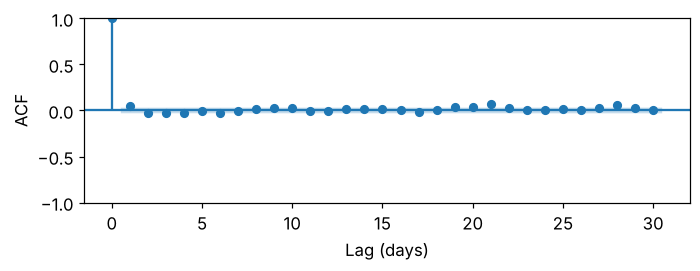

In [ ]:
t0 = time.time()
rf = RandomForestRegressor(**study.best_params, random_state=SEED, n_jobs=-1, oob_score=True, bootstrap=True)
rf.fit(X_train, y_train)
res_train = (y_train - rf.oob_prediction_).values     

aic = []
for p_ in range(0, 6):
    for q_ in range(0, 6):
        try:
            aic.append(((p_, 0, q_), ARIMA(res_train, order=(p_, 0, q_)).fit().aic))
        except Exception:
            pass
best_order = min(aic, key=lambda t: t[1])[0]
arima_res = ARIMA(res_train, order=best_order).fit()
train_time = time.time() - t0
print(f"Orde ARIMA terpilih (AIC): {best_order}")
print(f"Waktu training RF + seleksi & fit ARIMA: {train_time:.1f} s")

lb = acorr_ljungbox(res_train, lags=[7, 14], return_df=True)
print("\nLjung-Box residual OOB RF (data latih):"); print(lb.round(4))

fig, ax = plt.subplots(figsize=(6.5, 2.6))
plot_acf(res_train, lags=30, ax=ax, title='')
ax.set_xlabel('Lag (days)'); ax.set_ylabel('ACF')
plt.tight_layout(); plt.savefig('figs/fig_resid_acf.png', bbox_inches='tight'); plt.show()

In [ ]:
t0 = time.time()
pred_rf = rf.predict(X_test)
res_test = y_test.values - pred_rf
arima_all = arima_res.append(res_test, refit=False)
res_hat = arima_all.predict(start=len(res_train), end=len(res_train) + len(res_test) - 1)
pred_hybrid = pred_rf + res_hat
infer_ms = (time.time() - t0) / len(y_test) * 1000

pred_persist = X_test['pm10_lag_1'].values
ar_pm = ARIMA(y_train.values, order=(5, 1, 0)).fit()
pred_arima = ar_pm.append(y_test.values, refit=False).predict(start=len(y_train), end=len(y_train) + len(y_test) - 1)
xgb = XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=SEED).fit(X_train, y_train)
pred_xgb = xgb.predict(X_test)

def metrics(y, p): return np.sqrt(mean_squared_error(y, p)), mean_absolute_error(y, p), r2_score(y, p)
rows = [('Persistence (y_t = y_{t-1})', pred_persist), ('ARIMA(5,1,0), rolling one-step', pred_arima),
        ('XGBoost (same 18 features, untuned)', pred_xgb), ('Random Forest, Optuna-tuned', pred_rf),
        (f'Hybrid RF + ARIMA{best_order} (proposed)', pred_hybrid)]
bench = pd.DataFrame([(n, *metrics(y_test, p)) for n, p in rows], columns=['Model', 'RMSE', 'MAE', 'R2'])
print(bench.round(4).to_string(index=False))
print(f"\nInference: {infer_ms:.3f} ms per hari")
rf_rmse, hy_rmse = bench.RMSE.iloc[3], bench.RMSE.iloc[4]
print(f"Perubahan RMSE hybrid vs RF : {(rf_rmse - hy_rmse) / rf_rmse * 100:.2f}%")
print(f"Perubahan RMSE RF vs persistence: {(bench.RMSE.iloc[0] - rf_rmse) / bench.RMSE.iloc[0] * 100:.2f}%")
print(f"Perubahan MAE  RF vs persistence: {(bench.MAE.iloc[0] - bench.MAE.iloc[3]) / bench.MAE.iloc[0] * 100:.2f}%")

                                Model    RMSE     MAE     R2
          Persistence (y_t = y_{t-1}) 17.7462 11.9569 0.0815
       ARIMA(5,1,0), rolling one-step 15.2335 10.6963 0.3232
  XGBoost (same 18 features, untuned) 16.5184 12.0912 0.2042
          Random Forest, Optuna-tuned 14.8227 10.5471 0.3592
Hybrid RF + ARIMA(5, 0, 4) (proposed) 14.7293 10.3392 0.3672

Inference: 0.062 ms per hari
Perubahan RMSE hybrid vs RF : 0.63%
Perubahan RMSE RF vs persistence: 16.47%
Perubahan MAE  RF vs persistence: 11.79%


In [ ]:
def diebold_mariano(e1, e2, h=1):
    d = e1 ** 2 - e2 ** 2; n = len(d)
    stat = d.mean() / np.sqrt(d.var(ddof=0) / n)
    stat *= np.sqrt((n + 1 - 2 * h + h * (h - 1) / n) / n)     
    return stat, 2 * (1 - stats.t.cdf(abs(stat), df=n - 1))
y = y_test.values; e = {n: y - p for n, p in rows}
names = [r[0] for r in rows]
pairs = [(names[0], names[3]), (names[1], names[3]), (names[2], names[3]), (names[3], names[4]),
         (names[0], names[4]), (names[1], names[4]), (names[2], names[4])]
print("Diebold–Mariano (loss = squared error; DM > 0 -> model kedua lebih akurat)")
for a, b in pairs:
    s, pv = diebold_mariano(e[a], e[b]); print(f"{a:38s} vs {b:38s}: DM = {s:6.3f}, p = {pv:.4f}")

Diebold–Mariano (loss = squared error; DM > 0 -> model kedua lebih akurat)
Persistence (y_t = y_{t-1})            vs Random Forest, Optuna-tuned           : DM =  3.582, p = 0.0004
ARIMA(5,1,0), rolling one-step         vs Random Forest, Optuna-tuned           : DM =  1.954, p = 0.0510
XGBoost (same 18 features, untuned)    vs Random Forest, Optuna-tuned           : DM =  7.567, p = 0.0000
Random Forest, Optuna-tuned            vs Hybrid RF + ARIMA(5, 0, 4) (proposed) : DM =  1.380, p = 0.1680
Persistence (y_t = y_{t-1})            vs Hybrid RF + ARIMA(5, 0, 4) (proposed) : DM =  3.748, p = 0.0002
ARIMA(5,1,0), rolling one-step         vs Hybrid RF + ARIMA(5, 0, 4) (proposed) : DM =  2.305, p = 0.0214
XGBoost (same 18 features, untuned)    vs Hybrid RF + ARIMA(5, 0, 4) (proposed) : DM =  7.688, p = 0.0000


## 5. Ablation (RF 100 tree + ARIMA residual, setting yang sama)

In [11]:
A = ['so2_lag_1', 'co_lag_1', 'o3_lag_1', 'no2_lag_1']
B = A + [f'pm10_lag_{i}' for i in range(1, 8)] + ['pm10_ma_3', 'pm10_ma_7', 'pm10_std_7']
C = FEATS
abl = []
for name, cols in [('A: lagged pollutants only', A), ('B: A + PM10 lags & rolling stats', B), ('C: B + interaction & calendar (full)', C)]:
    m = RandomForestRegressor(n_estimators=100, random_state=SEED, n_jobs=-1, oob_score=True).fit(X_train[cols], y_train)
    r = (y_train - m.oob_prediction_).values
    a = ARIMA(r, order=best_order).fit()
    pr = m.predict(X_test[cols]); rt = y_test.values - pr
    rh = a.append(rt, refit=False).predict(start=len(r), end=len(r) + len(rt) - 1)
    abl.append((name, len(cols), *metrics(y_test, pr + rh)))
abl = pd.DataFrame(abl, columns=['Configuration', '#Features', 'RMSE', 'MAE', 'R2'])
print(abl.round(4).to_string(index=False))

                       Configuration  #Features    RMSE     MAE     R2
           A: lagged pollutants only          4 16.4962 12.1798 0.2063
    B: A + PM10 lags & rolling stats         14 15.2441 10.9062 0.3222
C: B + interaction & calendar (full)         18 15.1008 10.8192 0.3349


## 6. Error per stasiun pelapor & kejadian ekstrem

In [12]:
err = pd.DataFrame({'station': test['station'].values, 'y': y, 'p': pred_hybrid})
per_st = err.groupby('station').apply(lambda g: pd.Series({'n_days': len(g),
            'RMSE': np.sqrt(np.mean((g.y - g.p) ** 2)), 'MAE': np.mean(np.abs(g.y - g.p)), 'mean_PM10': g.y.mean()}))
print(per_st.round(2))
ext = y >= 101
print(f"\nHari ekstrem (PM10 >= 101, 'Tidak Sehat') di test set: {ext.sum()} | RMSE = {np.sqrt(np.mean((y[ext] - pred_hybrid[ext]) ** 2)):.2f}")
print(f"Bias rata-rata hybrid (pred - aktual): {np.mean(pred_hybrid - y):.2f}")

                      n_days   RMSE    MAE  mean_PM10
station                                              
DKI1 (Bunderan HI)      64.0  12.87   9.93      42.55
DKI2 (Kelapa Gading)   136.0  13.86  11.33      52.65
DKI3 (Jagakarsa)       168.0  11.41   8.64      45.70
DKI4 (Lubang Buaya)    524.0  15.90  10.32      63.62
DKI5 (Kebon Jeruk)     151.0  15.28  11.60      48.24

Hari ekstrem (PM10 >= 101, 'Tidak Sehat') di test set: 8 | RMSE = 85.57
Bias rata-rata hybrid (pred - aktual): -1.22


## 7. Visualisasi prediksi

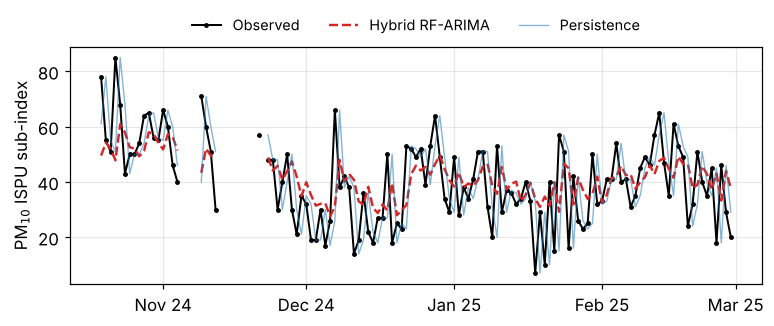

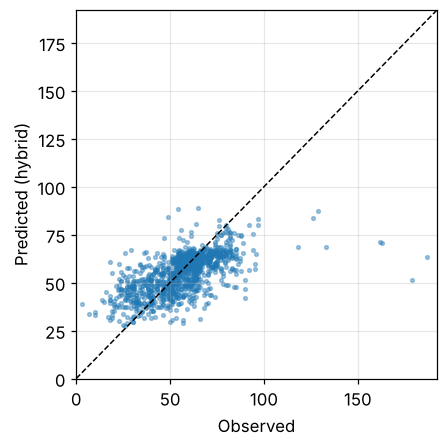

In [ ]:
import matplotlib.dates as mdates
N = 120
plot_df = pd.DataFrame({'obs': y, 'hyb': pred_hybrid, 'per': pred_persist}, index=y_test.index).iloc[-N:]
plot_df = plot_df.asfreq('D')       
fig, ax = plt.subplots(figsize=(7.2, 3.1))
ax.plot(plot_df.index, plot_df.obs, color='black', lw=1.3, marker='o', ms=2.2, label='Observed')
ax.plot(plot_df.index, plot_df.hyb, color='#d62728', lw=1.6, ls='--', label='Hybrid RF-ARIMA')
ax.plot(plot_df.index, plot_df.per, color='#1f77b4', lw=0.9, alpha=0.55, label='Persistence')
ax.xaxis.set_major_locator(mdates.MonthLocator()); ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %y'))
ax.set_ylabel('PM$_{10}$ ISPU sub-index'); ax.grid(alpha=0.3)
ax.legend(loc='lower center', bbox_to_anchor=(0.5, 1.0), ncol=3, frameon=False, fontsize=9.5)
plt.tight_layout(); plt.savefig('figs/fig_forecast.png', bbox_inches='tight'); plt.show()

fig, ax = plt.subplots(figsize=(4.2, 4.2))
ax.scatter(y, pred_hybrid, s=6, alpha=0.4, color='#1f77b4')
lim = [0, max(y.max(), pred_hybrid.max()) + 5]; ax.plot(lim, lim, 'k--', lw=1)
ax.set_xlim(lim); ax.set_ylim(lim); ax.set_xlabel('Observed'); ax.set_ylabel('Predicted (hybrid)'); ax.grid(alpha=0.3)
plt.tight_layout(); plt.savefig('figs/fig_scatter.png', bbox_inches='tight'); plt.show()

## 8. Interpretabilitas: TreeSHAP pada RF akhir

Mean |SHAP|:
pm10_ma_3        2.582
pm10_ma_7        2.489
pm10_lag_1       2.475
season           1.348
o3_lag_1         1.063
co_x_o3_lag_1    0.521
no2_lag_1        0.402
month            0.363
pm10_lag_7       0.322
so2_lag_1        0.311
pm10_lag_5       0.290
pm10_lag_2       0.258
pm10_lag_4       0.230
pm10_lag_3       0.222
pm10_lag_6       0.203
pm10_std_7       0.149
co_lag_1         0.078
is_weekend       0.032
dtype: float64


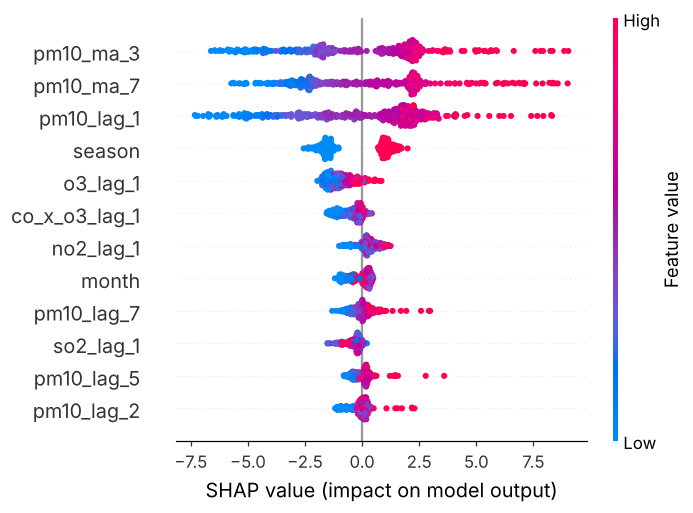

Mean SHAP co_x_o3_lag_1 | dry season: -0.191 | wet season: -0.811
Spearman(co_x_o3_lag_1, SHAP): 0.829


In [14]:
explainer = shap.TreeExplainer(rf)
X_shap = X_test.sample(min(400, len(X_test)), random_state=SEED)
sv = explainer.shap_values(X_shap)
imp = pd.Series(np.abs(sv).mean(0), index=X_shap.columns).sort_values(ascending=False)
print("Mean |SHAP|:"); print(imp.round(3))

plt.figure()
shap.summary_plot(sv, X_shap, max_display=12, show=False, plot_size=(6.5, 4.8))
plt.tight_layout(); plt.savefig('figs/fig_shap.png', bbox_inches='tight'); plt.show()

j = list(X_shap.columns).index('co_x_o3_lag_1')
dry = X_shap['season'] == 1
print(f"Mean SHAP co_x_o3_lag_1 | dry season: {sv[dry.values, j].mean():.3f} | wet season: {sv[~dry.values, j].mean():.3f}")
print(f"Spearman(co_x_o3_lag_1, SHAP): {stats.spearmanr(X_shap['co_x_o3_lag_1'], sv[:, j]).correlation:.3f}")